# Exploratory Data Analysis (EDA) on Retail Sales Dataset

### Oasis Infobyte Data Analytics Internship – Task 1

**Prepared by:** Mohtasim Ahmed Awan

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to identify meaningful insights into customer purchasing behavior, sales trends, product performance, and demographic patterns. The analysis aims to clean and explore the data, generate visualizations, interpret key findings, and provide business recommendations that can support data-driven decision-making.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries imported succesfully!")

All libraries imported succesfully!


In [3]:
import os
os.getcwd()

'C:\\Users\\hp\\Documents\\Oasis Infobyte Tasks or Projects Documents\\Retail Sales Dataset\\Extracted Dataset'

In [4]:
import os
os.listdir()

['.ipynb_checkpoints', 'EDA_Retail_Sales.ipynb', 'retail_sales_dataset.csv']

In [6]:
#loading the Dataset
df=pd.read_csv("retail_sales_dataset.csv")

In [7]:
#Displaying the first 5 rows 
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [8]:
#Checking no.of rows and columns
df.shape

(1000, 9)

In [9]:
#Displaying DataSet Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [10]:
#Checking Missing Values
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [11]:
#Descriptive Statistics
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [16]:
##Descriptive Statistics
#Mean
print("Mean")
print(df.mean(numeric_only=True))
#Median
print("Median")
print(df.median(numeric_only=True))
#Mode
print("Mode")
print(df.mode().iloc[0])
#Standard Deviation
print("Standard Deviation")
print(df.std(numeric_only=True))

Mean
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64
Median
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64
Mode
Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0
Product Category      Clothing
Quantity                   4.0
Price per Unit            50.0
Total Amount              50.0
Name: 0, dtype: object
Standard Deviation
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


### Observations

- The average customer age is approximately 41 years.
- Customers purchase around 2 to 3 items per transaction on average.
- The average sales amount per transaction is 456.
- The median total amount is 135, which is much lower than the mean, indicating that some high-value purchases increase the average.
- The high standard deviation of Total Amount shows considerable variation in customer spending.

In [18]:
#Date Conversion
#Convert Date Column into Date Time Format
df["Date"]=pd.to_datetime(df["Date"])

In [19]:
#Verifying the Conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


Feature Engineering

In [20]:
# Extract Month and Quarter from Date
df["Month"]=df["Date"].dt.month_name()
df["Quarter"]=df["Date"].dt.quarter


In [21]:
#Displaying the Updated DataSet
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2


Monthly Sales Trend Analysis

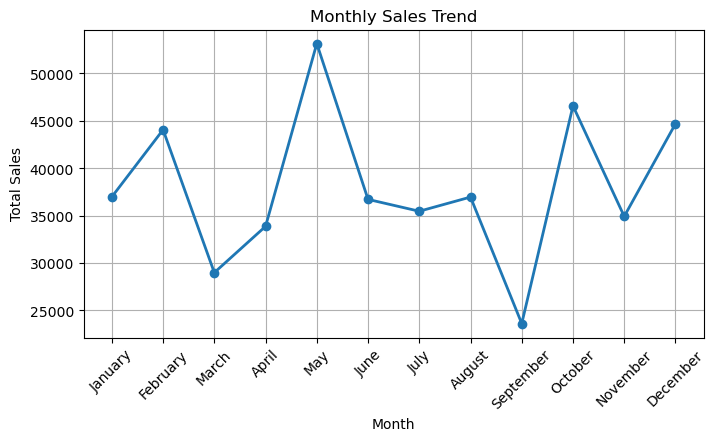

In [24]:
#Calculating Total Sales for Each Month
monthly_sales=df.groupby("Month")["Total Amount"].sum()
#Arranging months in calendar order
month_order=["January","February","March","April","May","June","July","August","September","October","November","December"]
monthly_sales=monthly_sales.reindex(month_order)
#Plotting the monthly sales trend
plt.figure(figsize=(8,4))
plt.plot(monthly_sales.index,monthly_sales.values,marker='o',linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [26]:
print(monthly_sales)

Month
January      36980
February     44060
March        28990
April        33870
May          53150
June         36715
July         35465
August       36960
September    23620
October      46580
November     34920
December     44690
Name: Total Amount, dtype: int64


### Observation

- Sales fluctuate throughout the year rather than following a steady increasing or decreasing trend.
- May recorded the highest total sales (53,150), indicating peak customer demand.
- September recorded the lowest total sales (23,620), suggesting weaker sales during that month.
- October, December, and February also showed relatively strong sales performance.
- These trends can help businesses plan promotions, inventory, and staffing during high- and low-sales periods.

Quarterly Sales Trend Analysis

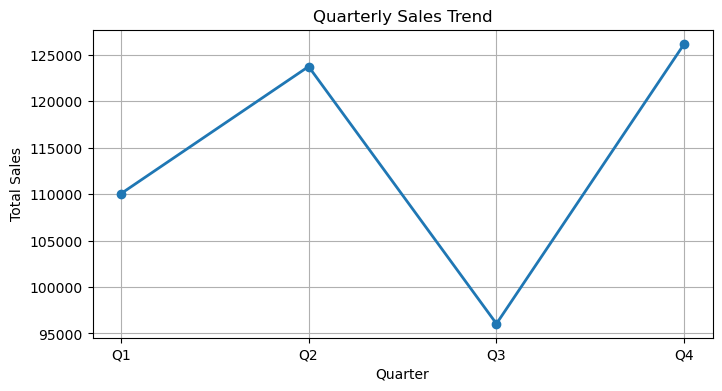

In [27]:
# Calculate total sales for each quarter
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

# Plot quarterly sales
plt.figure(figsize=(8,4))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks([1,2,3,4], ["Q1","Q2","Q3","Q4"])
plt.grid(True)

plt.show()

In [28]:
print(quarterly_sales)

Quarter
1    110030
2    123735
3     96045
4    126190
Name: Total Amount, dtype: int64


### Observation

- Quarterly sales show noticeable variation across the year.
- Q4 recorded the highest total sales (126,190), indicating the strongest business performance.
- Q2 followed closely with total sales of 123,735.
- Q3 recorded the lowest total sales (96,045), suggesting a slowdown in customer purchases.
- The higher sales in Q2 and Q4 may indicate seasonal demand or successful promotional periods.

## Customer Demographics Analysis
### Gender Distribution

Gender
Female    510
Male      490
Name: count, dtype: int64


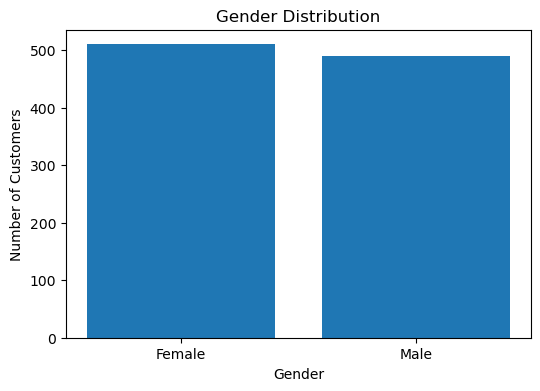

In [29]:
# Count male and female customers
gender_count = df["Gender"].value_counts()

print(gender_count)

# Plot gender distribution
plt.figure(figsize=(6,4))

plt.bar(gender_count.index, gender_count.values)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [30]:
print(gender_count)

Gender
Female    510
Male      490
Name: count, dtype: int64


### Observation

- The dataset contains 510 female customers and 490 male customers.
- The customer base is almost evenly distributed between both genders.
- Female customers slightly outnumber male customers, but the difference is very small.
- This balanced distribution suggests that products and marketing strategies can be designed to appeal to both genders.

### Age Group Distribution

Age Group
18-25    148
26-35    205
36-45    202
46-55    229
56-65    195
Name: count, dtype: int64


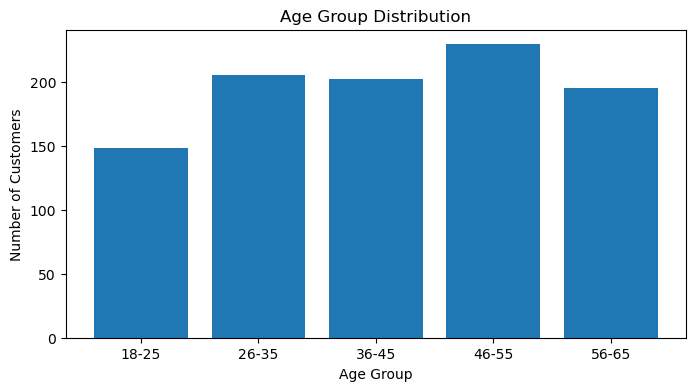

In [31]:
# Create age groups
bins = [18, 25, 35, 45, 55, 65]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

# Count customers in each age group
age_group = df["Age Group"].value_counts().sort_index()

print(age_group)

# Plot age group distribution
plt.figure(figsize=(8,4))

plt.bar(age_group.index.astype(str), age_group.values)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

In [33]:
print(age_group)

Age Group
18-25    148
26-35    205
36-45    202
46-55    229
56-65    195
Name: count, dtype: int64


### Observation

- Customers aged 46–55 form the largest customer group (229 customers).
- The 26–35 and 36–45 age groups also represent a significant portion of the customer base.
- The 18–25 age group has the fewest customers (148).
- The customer distribution suggests that middle-aged customers contribute a large share of the business, making them an important target for marketing campaigns.

## Product Category Analysis
### Revenue by Product Category

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


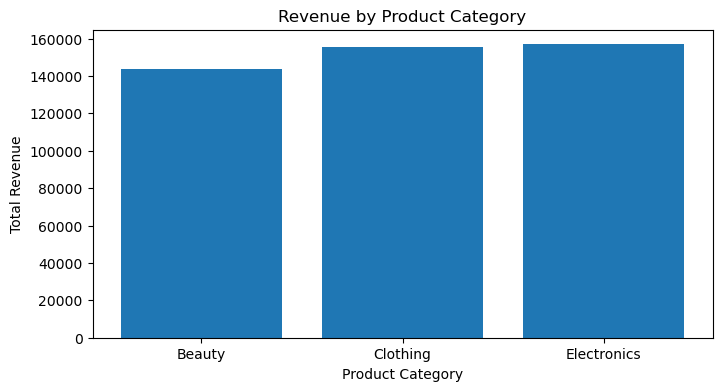

In [34]:
# Calculate total revenue by product category
category_sales = df.groupby("Product Category")["Total Amount"].sum()

print(category_sales)

# Plot revenue by category
plt.figure(figsize=(8,4))

plt.bar(category_sales.index, category_sales.values)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.show()

In [35]:
print(category_sales)

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


### Observation

- Electronics generated the highest total revenue (156,905).
- Clothing was the second highest revenue-generating category (155,580).
- Beauty generated the lowest revenue (143,515).
- The revenue difference between Electronics and Clothing is relatively small, indicating strong customer demand for both categories.
- Businesses can focus on promoting Electronics and Clothing while developing strategies to increase Beauty product sales.

## Top-Selling Products Analysis

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


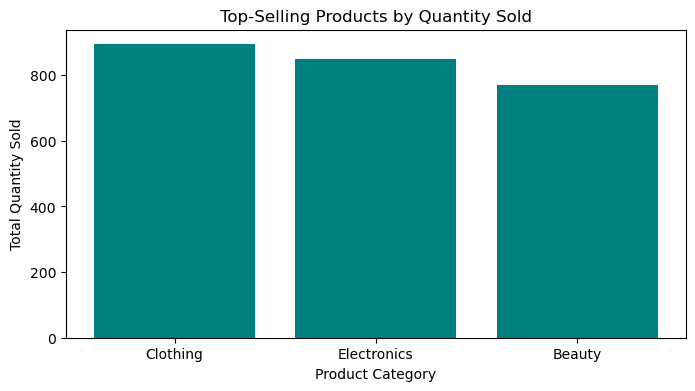

In [40]:
# Top-selling products by quantity sold
# Note: this dataset records sales at the Product Category level
# (Transaction ID, Date, Customer ID, Gender, Age, Product Category,
# Quantity, Price per Unit, Total Amount) — there is no individual
# product-name column, so "top products" is ranked by category.

top_products = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)

print(top_products)

plt.figure(figsize=(8,4))
plt.bar(top_products.index, top_products.values, color="teal")
plt.title("Top-Selling Products by Quantity Sold")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.show()

In [41]:
print(top_products)

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


### Observation

- This dataset records sales at the Product Category level rather than individual product names, so the "top-selling products" analysis is ranked by category.
- Clothing had the highest quantity sold, followed closely by Electronics and Beauty.
- Comparing this with the earlier revenue-by-category chart shows that quantity sold and revenue generated don't perfectly align — a category can sell more units but generate less total revenue if its average price per unit is lower.
- This suggests Price per Unit plays a major role in revenue performance, which is confirmed later in the correlation analysis.

## Correlation Heatmap

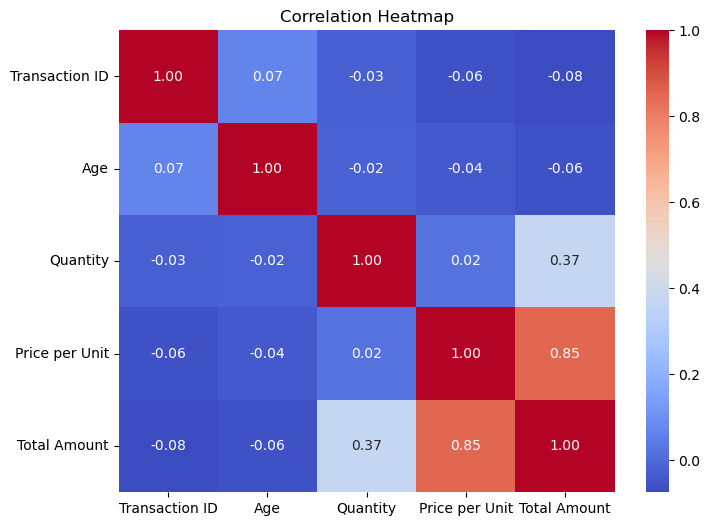

In [36]:
import seaborn as sns

# Select numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculate correlation
correlation = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [37]:
print(correlation)

                Transaction ID       Age  Quantity  Price per Unit  \
Transaction ID        1.000000  0.065191 -0.026623       -0.060837   
Age                   0.065191  1.000000 -0.023737       -0.038423   
Quantity             -0.026623 -0.023737  1.000000        0.017501   
Price per Unit       -0.060837 -0.038423  0.017501        1.000000   
Total Amount         -0.075034 -0.060568  0.373707        0.851925   

                Total Amount  
Transaction ID     -0.075034  
Age                -0.060568  
Quantity            0.373707  
Price per Unit      0.851925  
Total Amount        1.000000  


### Observation

- Price per Unit has a very strong positive correlation with Total Amount (0.85), indicating that higher-priced products contribute significantly to higher sales.
- Quantity has a moderate positive correlation with Total Amount (0.37), showing that purchasing more items increases the total transaction value.
- Age has a very weak negative correlation with Total Amount (-0.06), suggesting that customer age has little influence on spending.
- Transaction ID has no meaningful relationship with the other variables, as expected since it is only a unique identifier.
- Overall, Price per Unit is the strongest factor influencing Total Amount in this dataset.

## Distribution of Total Sales

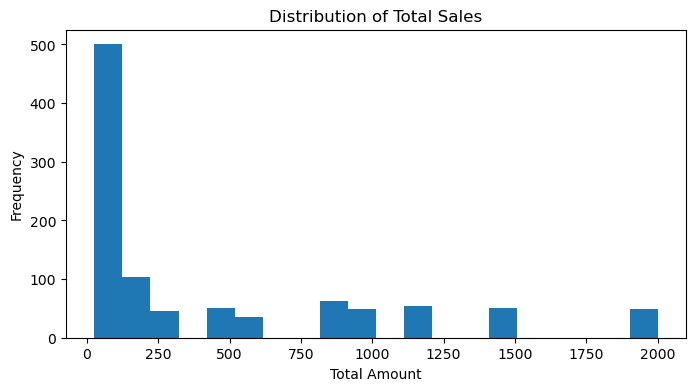

In [38]:
# Distribution of Total Amount

plt.figure(figsize=(8,4))

plt.hist(df["Total Amount"], bins=20)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.show()

In [39]:
df["Total Amount"].describe()

count    1000.000000
mean      456.000000
std       559.997632
min        25.000000
25%        60.000000
50%       135.000000
75%       900.000000
max      2000.000000
Name: Total Amount, dtype: float64

### Observation

- The average transaction value is 456.
- The median transaction value is 135, which is much lower than the mean, indicating that the sales distribution is positively (right) skewed.
- Most transactions have relatively low values, while a smaller number of high-value purchases increase the overall average.
- The maximum transaction value is 2,000, while the minimum is 25, showing a wide range of customer spending.
- The high standard deviation (559.99) further indicates considerable variation in transaction values.

## Business Recommendations

1. Increase inventory and promotional campaigns during high-performing months such as May and the fourth quarter.

2. Develop targeted marketing strategies for customers aged 46–55, as they represent the largest customer group.

3. Focus on Electronics and Clothing products since they generate the highest revenue.

4. Introduce promotional offers for Beauty products to improve their sales performance.

5. Since Price per Unit has the strongest relationship with Total Amount, businesses should optimize product pricing and promote premium products where appropriate.

6. While Clothing sells the highest volume of units, Electronics generates the most revenue overall — suggesting Electronics carries a higher average price per unit and may benefit from upselling/bundling strategies, while Clothing's high volume makes it a good candidate for loyalty or repeat-purchase promotions.

## Conclusion

This exploratory data analysis examined customer demographics, sales trends, and product performance using a retail sales dataset. The analysis revealed seasonal variations in sales, balanced customer demographics, and strong performance of the Electronics and Clothing categories. Correlation analysis showed that Price per Unit has the greatest influence on Total Amount. These insights can help businesses make informed decisions regarding inventory management, pricing strategies, and targeted marketing campaigns.